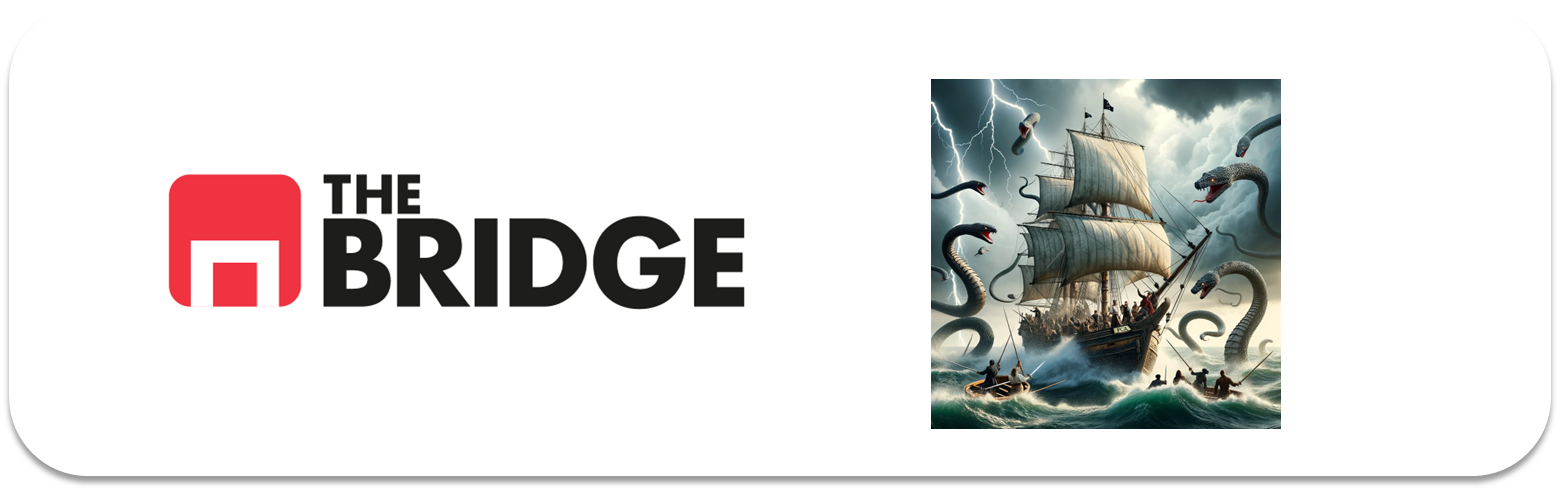

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import bootcampviztools as bt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import (SelectKBest, f_classif, mutual_info_classif,
                                       SelectFromModel, RFE, SequentialFeatureSelector)
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, recall_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


### 1. Entender el problema

* **Tipo de aprendizaje:** supervisado, **clasificacion binaria**.
* **Target:** `SeriousDlqin2yrs` -> ¿el cliente entrara en mora de mas de 90 dias en los proximos 2 años?
* **Metrica:** lo veremos al analizar el target, pero adelanto que sera el **recall medio**
  (`balanced_accuracy`) porque el target esta muy desbalanceado y **lo caro para el banco es NO detectar
  a un moroso** (falso negativo).

### 2. Cargar datos y primer vistazo

In [2]:
df = pd.read_csv("./data/credit_npo.csv")
print("Shape inicial:", df.shape)
df.head()

Shape inicial: (12537, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [4]:
# Nulos: el enunciado nos dice que nos deshagamos de las filas con nulos
print("Nulos por columna:")
print(df.isna().sum())

Nulos por columna:
SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64


In [5]:
# 1. Nos deshacemos de las filas con nulos
df = df.dropna()
print("Shape despues del dropna:", df.shape)

Shape despues del dropna: (11816, 11)


### 3. Analisis del target y eleccion de la metrica

SeriousDlqin2yrs
0    10986
1      830
Name: count, dtype: int64

SeriousDlqin2yrs
0    0.929756
1    0.070244
Name: proportion, dtype: float64


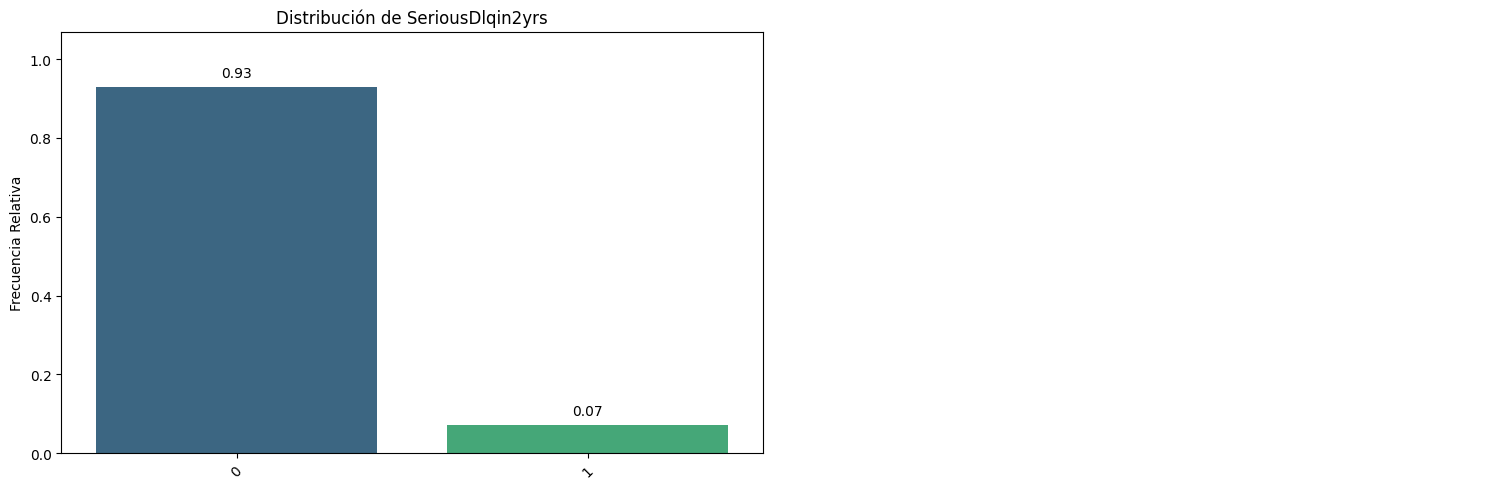

In [6]:
target = "SeriousDlqin2yrs"

print(df[target].value_counts())
print()
print(df[target].value_counts(normalize=True))

bt.pinta_distribucion_categoricas(df, [target], mostrar_valores=True, relativa=True)

*El target esta **muy desbalanceado**: solo un **~7%** son morosos. Esto descarta la `accuracy`
(un modelo que dijera "nadie es moroso" acertaria el 93% y seria inutil). Nos quedamos con el
**recall medio / `balanced_accuracy`**, que promedia el recall de las dos clases y por tanto castiga
al modelo si ignora a la minoria.*

### 4. Split train / test

*Lo hacemos **ANTES** de cualquier seleccion de features. Es fundamental: si seleccionamos features
mirando todo el dataset, el test "se cuela" en la decision y tendriamos **fuga de datos (data leakage)**.
Todos los selectores se ajustan **solo con train**.*

In [7]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target])

print("train:", train_set.shape, "| test:", test_set.shape)
print("% de morosos en train:", round(train_set[target].mean() * 100, 2))
print("% de morosos en test :", round(test_set[target].mean() * 100, 2))

train: (9452, 11) | test: (2364, 11)
% de morosos en train: 7.02
% de morosos en test : 7.02


### 5. Tratamiento de features: convertir las `NumberOf...` a categoricas

El enunciado pide convertir las `NumberOf...` que creamos conveniente a categoricas de 2-3 niveles.
Primero miramos como se distribuyen.

In [8]:
columnas_numberof = [col for col in df.columns if col.startswith("NumberOf") or col.startswith("NumberReal")]

for col in columnas_numberof:
    distribucion = df[col].value_counts(normalize=True).sort_index()
    porcentaje_ceros = distribucion.get(0, 0)
    print(f"\n{col} | valores unicos = {df[col].nunique()} | % de ceros = {porcentaje_ceros:.2%}")
    print((distribucion.head(6) * 100).round(2))


NumberOfTime30-59DaysPastDueNotWorse | valores unicos = 10 | % de ceros = 83.09%
NumberOfTime30-59DaysPastDueNotWorse
0    83.09
1    11.46
2     3.36
3     1.07
4     0.54
5     0.19
Name: proportion, dtype: float64

NumberOfOpenCreditLinesAndLoans | valores unicos = 43 | % de ceros = 0.95%
NumberOfOpenCreditLinesAndLoans
0    0.95
1    2.60
2    3.77
3    5.40
4    7.18
5    8.15
Name: proportion, dtype: float64



NumberOfTimes90DaysLate | valores unicos = 13 | % de ceros = 94.41%
NumberOfTimes90DaysLate
0    94.41
1     3.33
2     1.20
3     0.46
4     0.26
5     0.12
Name: proportion, dtype: float64

NumberRealEstateLoansOrLines | valores unicos = 16 | % de ceros = 35.82%
NumberRealEstateLoansOrLines
0    35.82
1    35.11
2    21.88
3     4.49
4     1.51
5     0.63
Name: proportion, dtype: float64

NumberOfTime60-89DaysPastDueNotWorse | valores unicos = 8 | % de ceros = 94.84%
NumberOfTime60-89DaysPastDueNotWorse
0    94.84
1     4.05
2     0.72
3     0.15
4     0.12
5     0.03
Name: proportion, dtype: float64

NumberOfDependents | valores unicos = 10 | % de ceros = 54.27%
NumberOfDependents
0.0    54.27
1.0    20.05
2.0    15.34
3.0     7.46
4.0     2.12
5.0     0.52
Name: proportion, dtype: float64


*Las tres features de **retrasos** (`NumberOfTime30-59`, `NumberOfTime60-89`, `NumberOfTimes90DaysLate`)
tienen mas de un **83% de ceros** y una cola larguisima con poquisimos casos. Son las candidatas perfectas a
categorizar en 3 niveles: **0 retrasos / 1 retraso / 2 o mas**. Asi le quitamos ruido a la cola y le damos al
modelo lo que de verdad importa: "¿se ha retrasado alguna vez y cuanto?".*

*Las otras (`NumberOfOpenCreditLinesAndLoans`, `NumberRealEstateLoansOrLines`, `NumberOfDependents`) tienen una
distribucion mas repartida y un significado mas "de cantidad", asi que las dejamos numericas.*

In [9]:
n_corto = "NumberOfTime30-59DaysPastDueNotWorse"
n_medio = "NumberOfTime60-89DaysPastDueNotWorse"
n_largo = "NumberOfTimes90DaysLate"

# bins = [-1, 0, 1, inf] -> 3 niveles: 0 retrasos | 1 retraso | 2 o mas
labels = [0, 1, 2]

for df_temp in [train_set, test_set]:
    df_temp["N30-59"] = pd.cut(df_temp[n_corto], bins=[-1, 0, 1, np.inf], labels=labels, right=True).astype(int)
    df_temp["N60-89"] = pd.cut(df_temp[n_medio], bins=[-1, 0, 1, np.inf], labels=labels, right=True).astype(int)
    df_temp["N90"]    = pd.cut(df_temp[n_largo], bins=[-1, 0, 1, np.inf], labels=labels, right=True).astype(int)

print(train_set[["N30-59", "N60-89", "N90"]].apply(lambda s: s.value_counts(normalize=True)))

     N30-59    N60-89       N90
0  0.829454  0.948688  0.944985
1  0.114896  0.040203  0.033432
2  0.055650  0.011109  0.021583


In [10]:
# Comprobamos que la codificacion "refleja" la tendencia a la morosidad:
# a mas retrasos, mas % de morosos -> la variable tiene sentido predictivo
for col in ["N30-59", "N60-89", "N90"]:
    print(f"\n% de morosos segun {col}:")
    print((train_set.groupby(col)[target].mean() * 100).round(2))


% de morosos segun N30-59:
N30-59
0     4.32
1    15.19
2    30.42
Name: SeriousDlqin2yrs, dtype: float64

% de morosos segun N60-89:
N60-89
0     5.49
1    29.74
2    56.19
Name: SeriousDlqin2yrs, dtype: float64

% de morosos segun N90:
N90
0     4.85
1    32.59
2    62.75
Name: SeriousDlqin2yrs, dtype: float64


*Perfecto: la relacion es **monotona y muy fuerte**. Por ejemplo, quien no se ha retrasado nunca 90 dias
es moroso en un ~4-5% de los casos, y quien lo ha hecho 2+ veces se dispara por encima del 50%. La
categorizacion tiene todo el sentido.*

In [11]:
# Definimos las listas de features con las que trabajaremos
features_num = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome",
                "NumberOfOpenCreditLinesAndLoans", "NumberRealEstateLoansOrLines", "NumberOfDependents"]
features_cat = ["N30-59", "N60-89", "N90"]

features = features_num + features_cat
print(f"{len(features)} features en juego:")
features

10 features en juego:


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberRealEstateLoansOrLines',
 'NumberOfDependents',
 'N30-59',
 'N60-89',
 'N90']

### 6.1 Analisis visual + filtrado por correlacion y umbral de covarianza

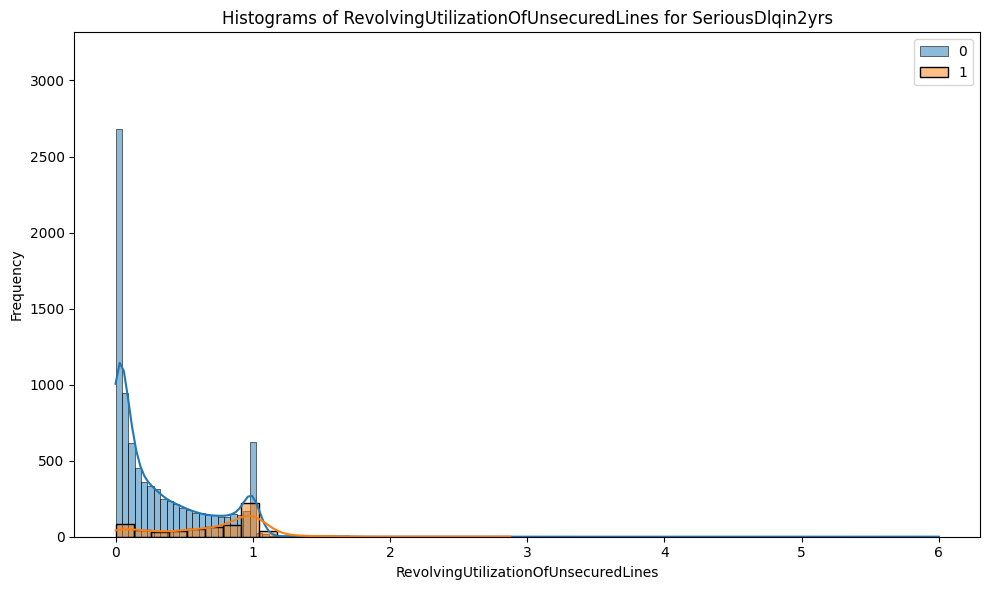

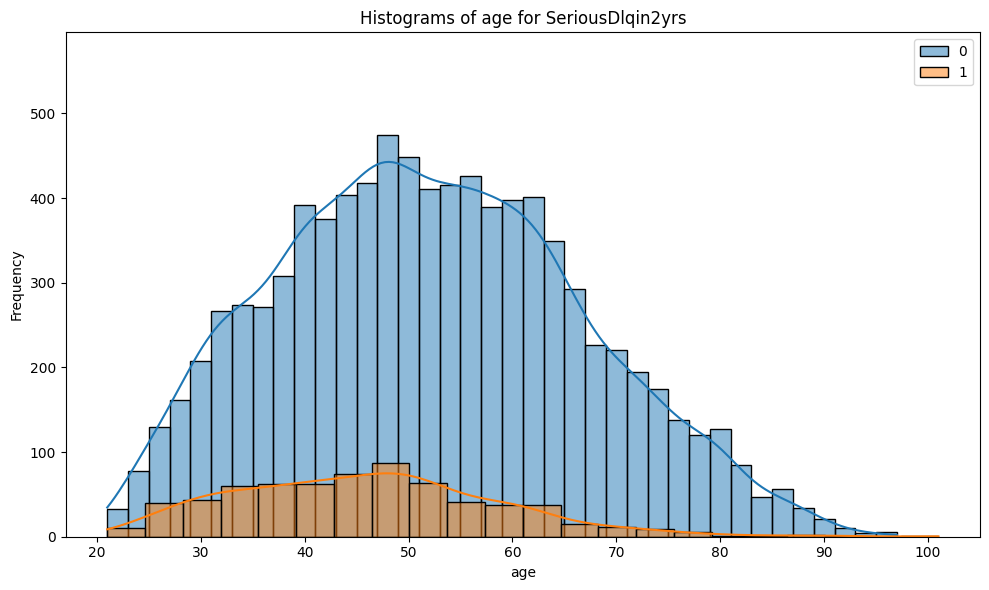

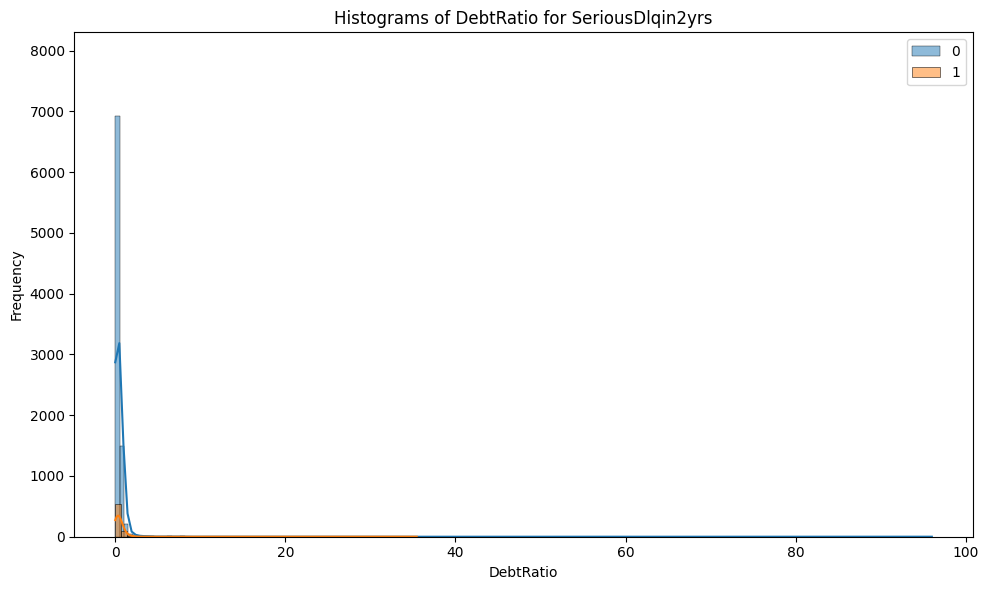

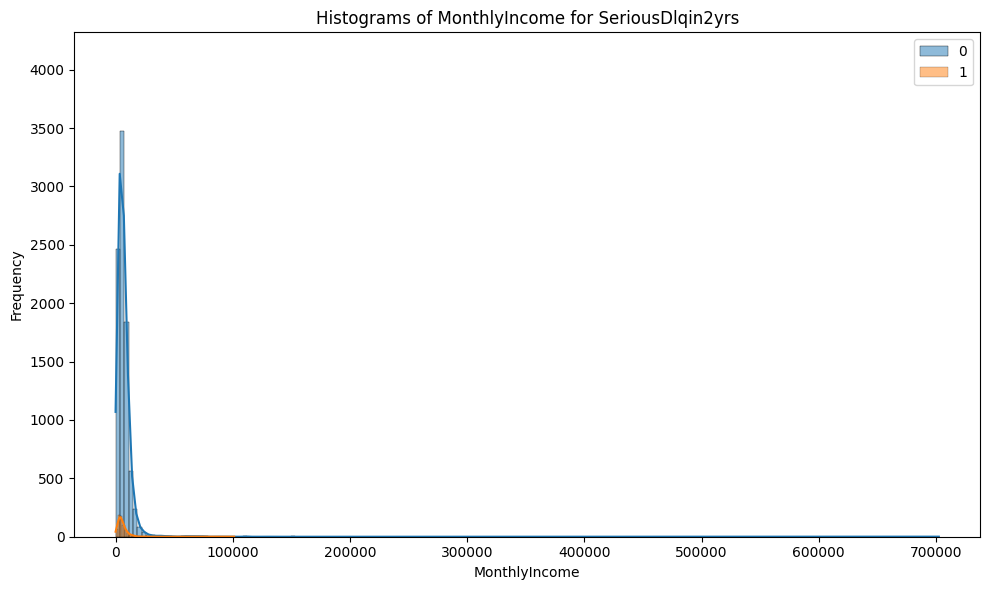

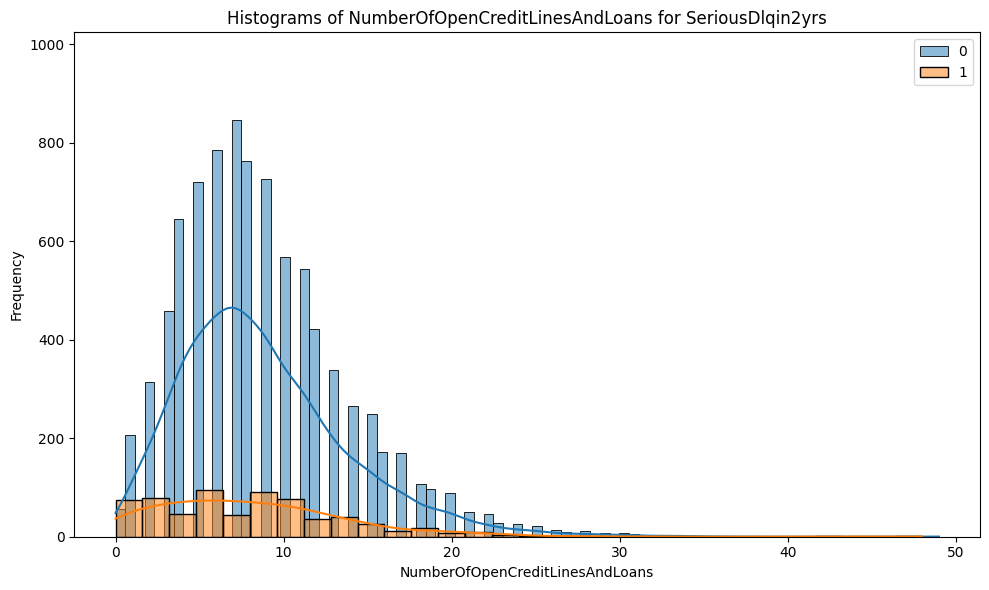

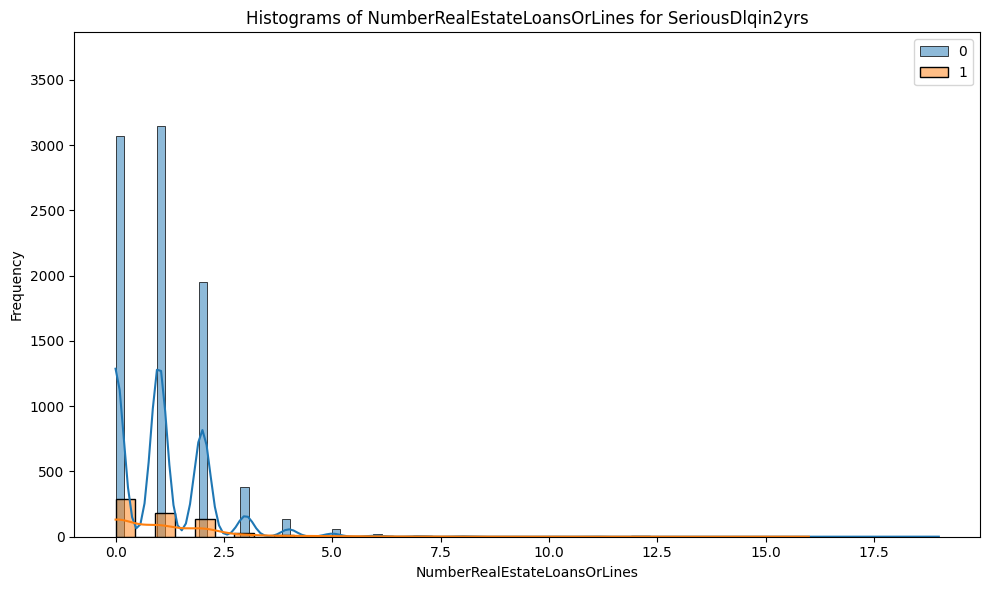

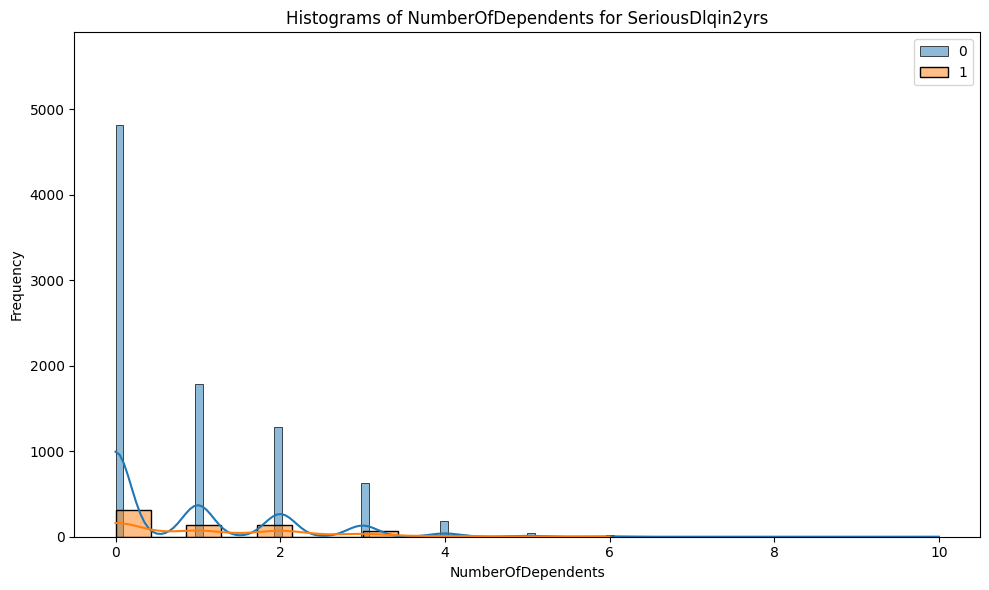

In [12]:
# Numericas vs target (categorico): miramos si las distribuciones se separan
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col, group_size=2)

*Nos fijamos en si las dos distribuciones (moroso / no moroso) **se desplazan** una respecto a la otra o
hay zonas dominadas por una clase. `RevolvingUtilizationOfUnsecuredLines` y `age` son las que mas separan;
`MonthlyIncome` y `DebtRatio` algo; el resto se superponen casi del todo.*

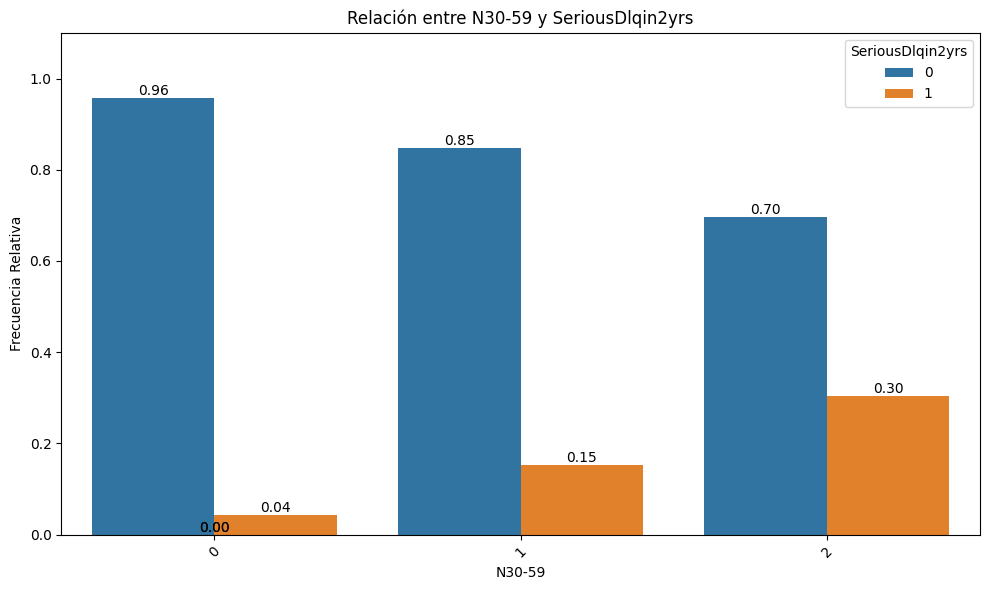

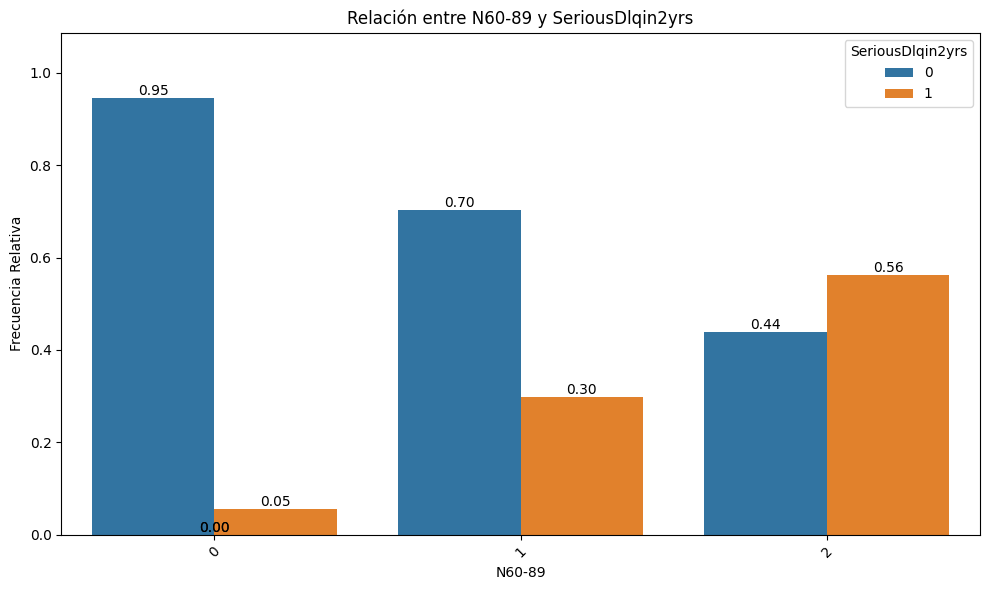

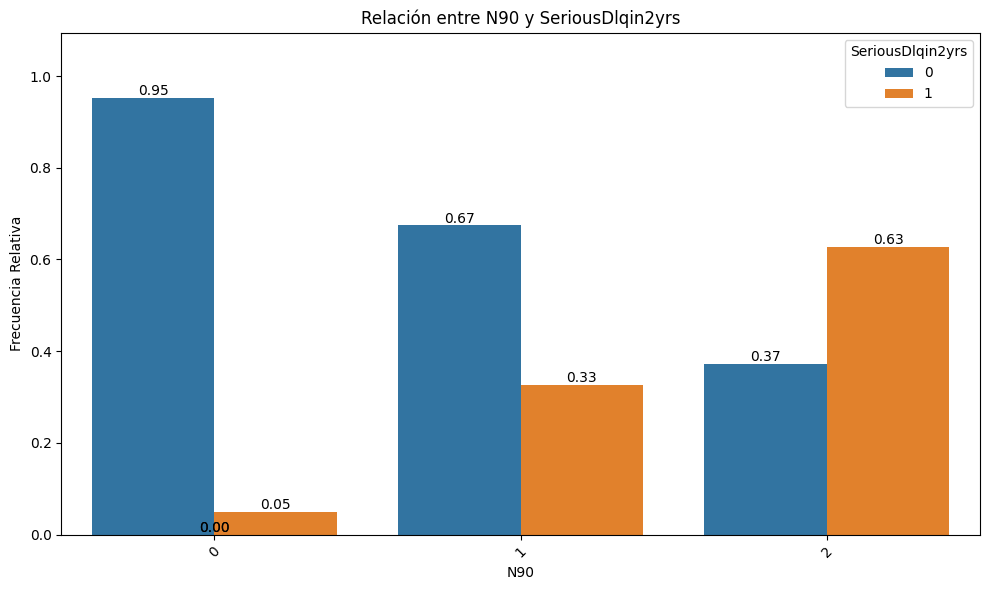

In [13]:
# Categoricas vs target: miramos si el reparto del target cambia entre categorias
for col in features_cat:
    bt.plot_categorical_relationship(train_set, col, target, show_values=True, relative_freq=True)

*Las tres categoricas de retrasos separan **muchisimo**: el % de morosos cambia radicalmente entre
nivel 0 y nivel 2. Son de primera division sin discusion.*

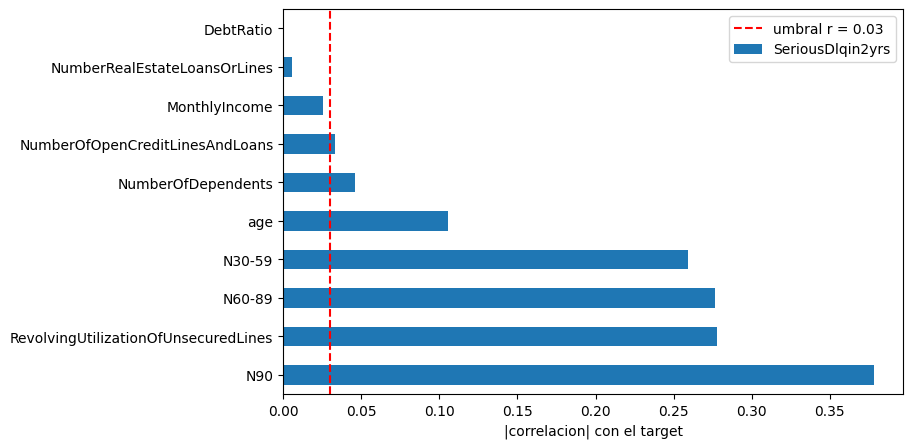

N90                                     0.377976
RevolvingUtilizationOfUnsecuredLines    0.277475
N60-89                                  0.276154
N30-59                                  0.259018
age                                     0.105251
NumberOfDependents                      0.046099
NumberOfOpenCreditLinesAndLoans         0.033514
MonthlyIncome                           0.025449
NumberRealEstateLoansOrLines            0.005770
DebtRatio                               0.000089
Name: SeriousDlqin2yrs, dtype: float64

In [14]:
# Filtrado por correlacion con el target
corr = train_set[features + [target]].corr()
serie_corr = np.abs(corr[target]).drop(target).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
serie_corr.plot(kind="barh")
plt.axvline(x=0.03, color="r", linestyle="--", label="umbral r = 0.03")
plt.xlabel("|correlacion| con el target")
plt.legend()
plt.show()

serie_corr

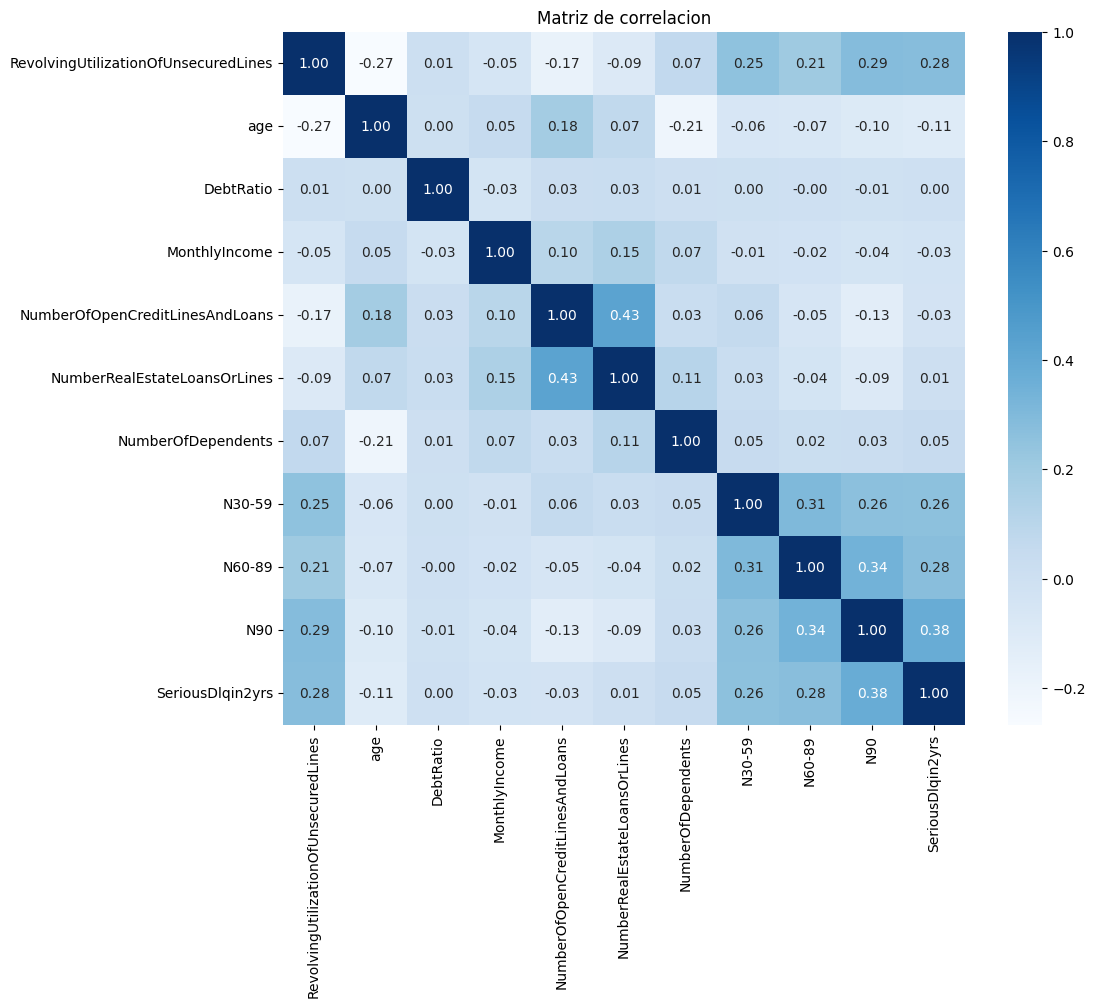

In [15]:
# Umbral de covarianza/correlacion ENTRE features: si dos features estan muy correlacionadas
# entre si, aportan lo mismo -> nos sobraria una (redundancia)
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de correlacion")
plt.show()

*Del heatmap: las tres `N30-59`, `N60-89`, `N90` estan correlacionadas **entre si** (~0.2-0.4), logico
porque quien se retrasa una vez tiende a retrasarse otras. Pero no llegan a niveles de redundancia total
(>0.8), asi que las mantenemos las tres. No hay ninguna pareja peligrosamente redundante.*

**Lista #1 (visual + filtrado):** nos quedamos con las 3 categoricas de retrasos (las que mas separan
visualmente) + las numericas con mayor correlacion con el target.

In [16]:
r_minimo = 0.03
features_visual = features_cat + [f for f in serie_corr[serie_corr >= r_minimo].index.to_list()
                                  if f in features_num]

# El enunciado limita a 6 features como maximo
features_visual = features_visual[:6]
print("LISTA 1 - visual/filtrado:", features_visual)

LISTA 1 - visual/filtrado: ['N30-59', 'N60-89', 'N90', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfDependents']


### 6.2 SelectKBest: ANOVA para las numericas + Mutual Information para las categoricas

In [17]:
# ANOVA (f_classif) para las NUMERICAS: compara las medias de cada grupo del target
selector_num = SelectKBest(f_classif, k=3)
selector_num.fit(train_set[features_num], train_set[target])

# Miramos los p-values: cuanto MENOR el p-value, mas significativa la feature
df_anova = pd.DataFrame({
    "feature": features_num,
    "F": selector_num.scores_,
    "p_value": selector_num.pvalues_
}).sort_values("p_value")

display(df_anova)
print("Elegidas por ANOVA:", list(selector_num.get_feature_names_out()))

,feature,F,p_value
0,RevolvingUtilizationOfUnsecuredLines,788.269908,1.161903e-166
1,age,105.857431,1.069354e-24
6,NumberOfDependents,20.125285,7.338830e-06
4,NumberOfOpenCreditLinesAndLoans,10.626153,1.118939e-03
3,MonthlyIncome,6.124270,1.335125e-02
5,NumberRealEstateLoansOrLines,0.314679,5.748361e-01
2,DebtRatio,0.000074,9.931332e-01


Elegidas por ANOVA: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfDependents']


In [18]:
# Mutual Information para las CATEGORICAS: cuanta informacion revela cada una sobre el target
selector_cat = SelectKBest(mutual_info_classif, k=3)
selector_cat.fit(train_set[features_cat], train_set[target])

df_mi = pd.DataFrame({
    "feature": features_cat,
    "mutual_info (nats)": selector_cat.scores_
}).sort_values("mutual_info (nats)", ascending=False)

display(df_mi)
print("Elegidas por Mutual Information:", list(selector_cat.get_feature_names_out()))

,feature,mutual_info (nats)
2,N90,0.035803
0,N30-59,0.023580
1,N60-89,0.020195


Elegidas por Mutual Information: ['N30-59', 'N60-89', 'N90']


In [19]:
features_filter = list(selector_num.get_feature_names_out()) + list(selector_cat.get_feature_names_out())
print("LISTA 2 - filter (ANOVA + MI):", features_filter, f"-> {len(features_filter)} features")

LISTA 2 - filter (ANOVA + MI): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfDependents', 'N30-59', 'N60-89', 'N90'] -> 6 features


### 6.3 Seleccion mediante un modelo intermedio (`SelectFromModel`)

*Usamos un RandomForest como modelo "proxy" y nos quedamos con las features cuya importancia supere la
**mediana**. Ojo al `class_weight="balanced"`: como el target esta desbalanceado, sin el, el modelo proxy
mediria la importancia pensando casi solo en la clase mayoritaria.*

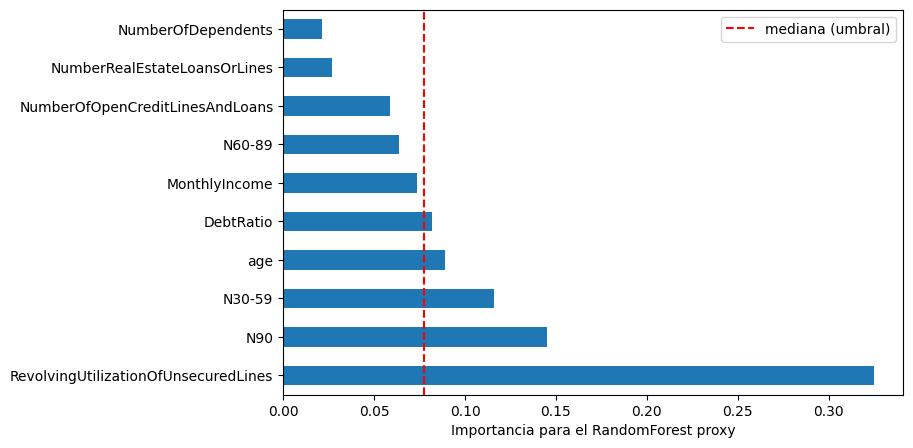

LISTA 3 - SelectFromModel: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'N30-59', 'N90'] -> 5 features


In [20]:
rf_selector = RandomForestClassifier(max_depth=10, random_state=42, class_weight="balanced")
selector_modelo = SelectFromModel(estimator=rf_selector, threshold="median")
selector_modelo.fit(train_set[features], train_set[target])

# Vemos las importancias que ha usado por debajo
importancias = pd.Series(selector_modelo.estimator_.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importancias.plot(kind="barh")
plt.axvline(x=np.median(importancias), color="r", linestyle="--", label="mediana (umbral)")
plt.xlabel("Importancia para el RandomForest proxy")
plt.legend()
plt.show()

features_modelo = list(selector_modelo.get_feature_names_out())
print("LISTA 3 - SelectFromModel:", features_modelo, f"-> {len(features_modelo)} features")

### 6.4 RFE (Recursive Feature Elimination)

*RFE entrena el modelo, tira la feature menos importante, y vuelve a empezar, hasta quedarse con las
que le pidamos. Le pedimos 6 (el maximo que permite el enunciado).*

In [21]:
rf_RFE = RandomForestClassifier(max_depth=10, random_state=42, class_weight="balanced")

rfe = RFE(estimator=rf_RFE, n_features_to_select=6, step=1)
rfe.fit(train_set[features], train_set[target])

# El ranking: 1 = seleccionada
display(pd.DataFrame(rfe.ranking_, columns=["ranking"], index=features).sort_values("ranking"))

features_RFE = list(rfe.get_feature_names_out())
print("LISTA 4 - RFE:", features_RFE, f"-> {len(features_RFE)} features")

,ranking
RevolvingUtilizationOfUnsecuredLines,1
age,1
DebtRatio,1
MonthlyIncome,1
N30-59,1
N90,1
N60-89,2
NumberOfOpenCreditLinesAndLoans,3
NumberRealEstateLoansOrLines,4
NumberOfDependents,5


LISTA 4 - RFE: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'N30-59', 'N90'] -> 6 features


### 6.5 SFS (Sequential Feature Selector)

*Al reves que RFE: empieza sin nada y va **añadiendo** la feature que mas mejora el score, una a una.
La ventaja es que **si mira la metrica que le digamos** (`balanced_accuracy`) y con validacion cruzada.
La desventaja: es "greedy" y tarda muchisimo (entrena un modelo por cada combinacion posible).*

In [22]:
rf_SFS = RandomForestClassifier(max_depth=10, random_state=42, class_weight="balanced")

sfs_forward = SequentialFeatureSelector(rf_SFS,
                                        n_features_to_select=5,
                                        cv=4,
                                        scoring="balanced_accuracy",
                                        n_jobs=-1)
sfs_forward.fit(train_set[features], train_set[target])

features_SFS = list(sfs_forward.get_feature_names_out())
print("LISTA 5 - SFS:", features_SFS, f"-> {len(features_SFS)} features")

LISTA 5 - SFS: ['RevolvingUtilizationOfUnsecuredLines', 'MonthlyIncome', 'NumberRealEstateLoansOrLines', 'N60-89', 'N90'] -> 5 features


### 6.6 Hard Voting sobre las 5 selecciones anteriores

*El hard-voting aqui no es mas que **contar** cuantas veces aparece cada feature en las 5 listas
anteriores y quedarnos con las mas votadas (maximo 6). Usamos `Counter`.*

,Votos
N90,5
RevolvingUtilizationOfUnsecuredLines,5
N30-59,4
age,4
N60-89,3
NumberOfDependents,2
DebtRatio,2
MonthlyIncome,2
NumberRealEstateLoansOrLines,1


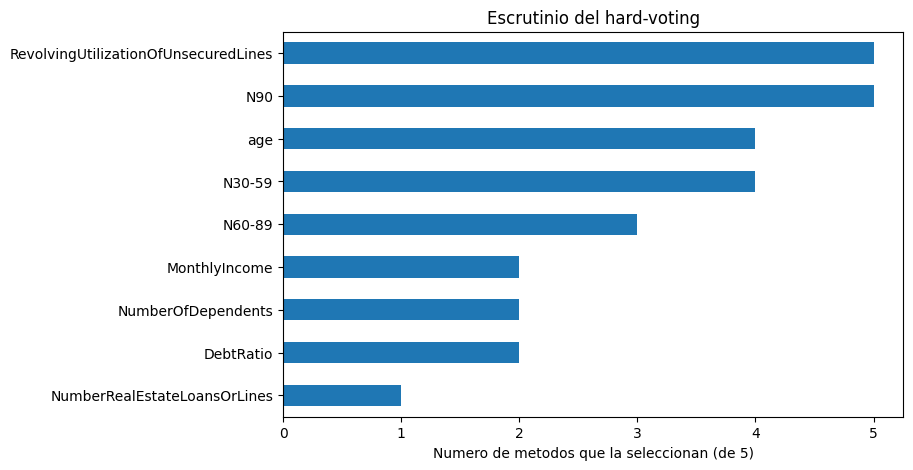

In [23]:
lista_total = features_visual + features_filter + features_modelo + features_RFE + features_SFS
votaciones = Counter(lista_total)

escrutinio = pd.DataFrame(votaciones.values(), columns=["Votos"], index=votaciones.keys()).sort_values("Votos", ascending=False)
display(escrutinio)

plt.figure(figsize=(8, 5))
escrutinio["Votos"].sort_values().plot(kind="barh")
plt.xlabel("Numero de metodos que la seleccionan (de 5)")
plt.title("Escrutinio del hard-voting")
plt.show()

In [24]:
features_hard_voting = escrutinio["Votos"].nlargest(6).index.to_list()
print("LISTA 6 - hard voting:", features_hard_voting, f"-> {len(features_hard_voting)} features")

LISTA 6 - hard voting: ['N90', 'RevolvingUtilizationOfUnsecuredLines', 'N30-59', 'age', 'N60-89', 'NumberOfDependents'] -> 6 features


In [25]:
# Resumen de las 6 listas
nombres = ["visual", "filter", "modelo", "rfe", "sfs", "voting"]
listas = [features_visual, features_filter, features_modelo, features_RFE, features_SFS, features_hard_voting]

for nombre, lista in zip(nombres, listas):
    print(f"{nombre:>8} ({len(lista)}): {lista}")

  visual (6): ['N30-59', 'N60-89', 'N90', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfDependents']
  filter (6): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfDependents', 'N30-59', 'N60-89', 'N90']
  modelo (5): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'N30-59', 'N90']
     rfe (6): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'N30-59', 'N90']
     sfs (5): ['RevolvingUtilizationOfUnsecuredLines', 'MonthlyIncome', 'NumberRealEstateLoansOrLines', 'N60-89', 'N90']
  voting (6): ['N90', 'RevolvingUtilizationOfUnsecuredLines', 'N30-59', 'age', 'N60-89', 'NumberOfDependents']


*Como decia el workout: **tenemos para todos los gustos**. Cada metodo mira una cosa distinta, asi que es normal que no coincidan. Ahora toca decidir con datos, no a ojo.*

### 7. Modelado: 3 modelos x 6 listas = 18 medidas

*Elegimos 3 modelos **basados en arboles** a proposito: asi nos ahorramos el escalado (a los arboles les
da igual la escala) y podemos comparar las listas de features en igualdad de condiciones. Los tres saben
manejar el desbalanceo con un hiperparametro (`class_weight` / `scale_pos_weight`).*

In [26]:
y_train = train_set[target]

# Ratio de desbalanceo para XGBoost
ratio_desbalanceo = len(train_set[train_set[target] == 0]) / len(train_set[train_set[target] == 1])
print("Ratio negativos/positivos:", round(ratio_desbalanceo, 2))

model_names = ["RandomForest", "XGBoost", "LightGBM"]
models = [
    RandomForestClassifier(max_depth=10, class_weight="balanced", random_state=42),
    XGBClassifier(max_depth=4, random_state=42, scale_pos_weight=ratio_desbalanceo),
    LGBMClassifier(class_weight="balanced", random_state=42, verbose=-100, n_jobs=-1),
]

resultados = []

for nombre, lista in zip(nombres, listas):
    X_train = train_set[lista]
    for model_name, modelo in zip(model_names, models):
        metrica = np.mean(cross_val_score(modelo, X_train, y_train, cv=5, scoring="balanced_accuracy"))
        resultados.append({"features_list": nombre, "n_features": len(lista),
                           "model": model_name, "avg_recall": metrica})
        print(f"{nombre:>8} | {model_name:>13} -> {metrica:.4f}")

df_resultados = pd.DataFrame(resultados)

Ratio negativos/positivos: 13.23


  visual |  RandomForest -> 0.7302


  visual |       XGBoost -> 0.7168


  visual |      LightGBM -> 0.7373


  filter |  RandomForest -> 0.7314


...

     sfs |  RandomForest -> 0.7208
     sfs |       XGBoost -> 0.7126


     sfs |      LightGBM -> 0.7129


  voting |  RandomForest -> 0.7355


  voting |       XGBoost -> 0.7168


  voting |      LightGBM -> 0.7373


In [27]:
df_resultados.sort_values("avg_recall", ascending=False)

,features_list,n_features,model,avg_recall
5,filter,6,LightGBM,0.737326
2,visual,6,LightGBM,0.737326
17,voting,6,LightGBM,0.737326
15,voting,6,RandomForest,0.735503
3,filter,6,RandomForest,0.731408
0,visual,6,RandomForest,0.730207
12,sfs,5,RandomForest,0.720784
6,modelo,5,RandomForest,0.717715
1,visual,6,XGBoost,0.716835
4,filter,6,XGBoost,0.716835


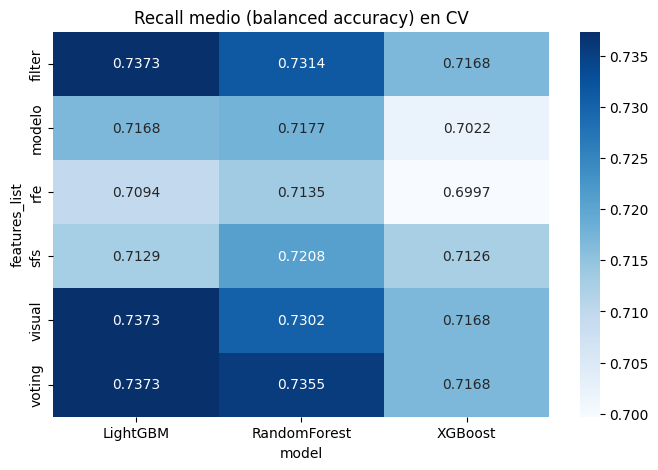

model,LightGBM,RandomForest,XGBoost
features_list,,,
filter,0.737326,0.731408,0.716835
modelo,0.716808,0.717715,0.702198
rfe,0.709416,0.713471,0.699709
sfs,0.712927,0.720784,0.712563
visual,0.737326,0.730207,0.716835
voting,0.737326,0.735503,0.716835


In [28]:
# Lo vemos como tabla cruzada, mucho mas facil de leer
tabla = df_resultados.pivot(index="features_list", columns="model", values="avg_recall")

plt.figure(figsize=(8, 5))
sns.heatmap(tabla, annot=True, fmt=".4f", cmap="Blues")
plt.title("Recall medio (balanced accuracy) en CV")
plt.show()

tabla

In [29]:
# El mejor de los 18
mejor = df_resultados.loc[df_resultados["avg_recall"].idxmax()]
print("MEJOR COMBINACION:")
print(mejor)

mejor_lista_nombre = mejor["features_list"]
mejor_modelo_nombre = mejor["model"]
mejor_lista = dict(zip(nombres, listas))[mejor_lista_nombre]

print(f"\n-> Modelo: {mejor_modelo_nombre}")
print(f"-> Lista de features: {mejor_lista_nombre} = {mejor_lista}")

MEJOR COMBINACION:
features_list      visual
n_features              6
model            LightGBM
avg_recall       0.737326
Name: 2, dtype: object

-> Modelo: LightGBM
-> Lista de features: visual = ['N30-59', 'N60-89', 'N90', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfDependents']


*El enunciado pide **"el conjunto mas sencillo con mas potencia"**. Antes de casarnos con el ganador,
miremos si hay alguna lista con **menos features** que rinda practicamente igual: en produccion, menos
features = menos datos que pedir, menos que mantener y un modelo mas explicable.*

In [30]:
# ¿Cual es la mejor combinacion para cada numero de features?
comparativa = df_resultados.sort_values("avg_recall", ascending=False).drop_duplicates("features_list")
display(comparativa[["features_list", "n_features", "model", "avg_recall"]])

mejor_score = df_resultados["avg_recall"].max()
print(f"\nMejor score absoluto: {mejor_score:.4f}")
print("\nListas que se quedan a menos de 1 punto porcentual del mejor:")
cercanas = comparativa[comparativa["avg_recall"] >= mejor_score - 0.01]
display(cercanas[["features_list", "n_features", "model", "avg_recall"]])

,features_list,n_features,model,avg_recall
5,filter,6,LightGBM,0.737326
2,visual,6,LightGBM,0.737326
17,voting,6,LightGBM,0.737326
12,sfs,5,RandomForest,0.720784
6,modelo,5,RandomForest,0.717715
9,rfe,6,RandomForest,0.713471



Mejor score absoluto: 0.7373

Listas que se quedan a menos de 1 punto porcentual del mejor:


,features_list,n_features,model,avg_recall
5,filter,6,LightGBM,0.737326
2,visual,6,LightGBM,0.737326
17,voting,6,LightGBM,0.737326


### 8. Optimizacion de hiperparametros del mejor modelo y evaluacion contra test

In [31]:
X_train = train_set[mejor_lista]
y_train = train_set[target]
X_test = test_set[mejor_lista]
y_test = test_set[target]

print("Entrenando con:", mejor_lista)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

Entrenando con: ['N30-59', 'N60-89', 'N90', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfDependents']
X_train: (9452, 6) | X_test: (2364, 6)


In [32]:
# Grid distinto segun el modelo ganador
grids = {
    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, 15],
        "min_samples_leaf": [1, 5, 20],
        "class_weight": ["balanced"],
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 4, 6],
        "scale_pos_weight": [ratio_desbalanceo],
    },
    "LightGBM": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [5, 10, 15],
        "num_leaves": [15, 31, 63],
        "class_weight": ["balanced"],
    },
}

modelo_base = dict(zip(model_names, models))[mejor_modelo_nombre]

grid = GridSearchCV(modelo_base,
                    param_grid=grids[mejor_modelo_nombre],
                    cv=5,
                    scoring="balanced_accuracy",
                    n_jobs=-1)
grid.fit(X_train, y_train)

print("Mejores hiperparametros:", grid.best_params_)
print("Mejor recall medio en CV:", round(grid.best_score_, 4))

Mejores hiperparametros: {'class_weight': 'balanced', 'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 15}
Mejor recall medio en CV: 0.767


=== MODELO FINAL - TEST ===
              precision    recall  f1-score   support

           0       0.98      0.78      0.87      2198
           1       0.20      0.74      0.32       166

    accuracy                           0.77      2364
   macro avg       0.59      0.76      0.59      2364
weighted avg       0.92      0.77      0.83      2364

Recall medio (balanced accuracy) en TEST: 0.7592
Recall medio en CV                     : 0.767


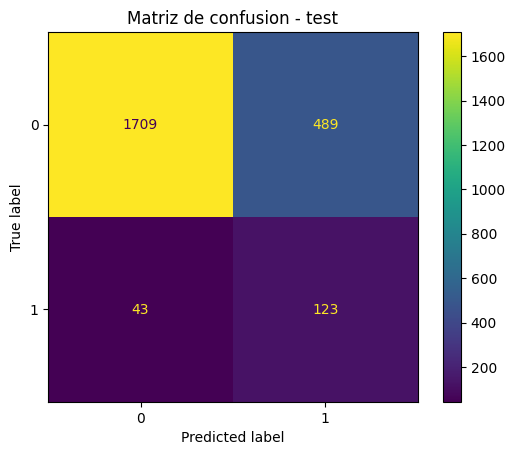

In [33]:
# EVALUACION FINAL CONTRA TEST
mejor_modelo = grid.best_estimator_
y_pred = mejor_modelo.predict(X_test)

print("=== MODELO FINAL - TEST ===")
print(classification_report(y_test, y_pred))
print("Recall medio (balanced accuracy) en TEST:", round(recall_score(y_test, y_pred, average="macro"), 4))
print("Recall medio en CV                     :", round(grid.best_score_, 4))

ConfusionMatrixDisplay.from_estimator(mejor_modelo, X_test, y_test)
plt.title("Matriz de confusion - test")
plt.show()

In [34]:
# Guardamos el resultado para compararlo con el EXTRA de PCA
resultado_final = recall_score(y_test, y_pred, average="macro")
print("Recall medio final (test):", round(resultado_final, 4))

Recall medio final (test): 0.7592


### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

*Ahora usamos **PCA como metodo de "seleccion"**. Ojo a las comillas: PCA no selecciona, **transforma**.
Crea componentes nuevas que son combinaciones de TODAS las features originales.

Dos cosas importantes que cambian respecto a lo anterior:
1. **Hay que escalar** antes de la PCA. Es obligatorio: la PCA busca direcciones de maxima varianza y sin
   escalar, `MonthlyIncome` (miles) aplastaria a `age` (decenas) o a `N90` (0-2) solo por su unidad.
2. Aqui usamos **todas** las features, porque la gracia de la PCA es justo esa: no tirar nada, sino
   condensarlo.*

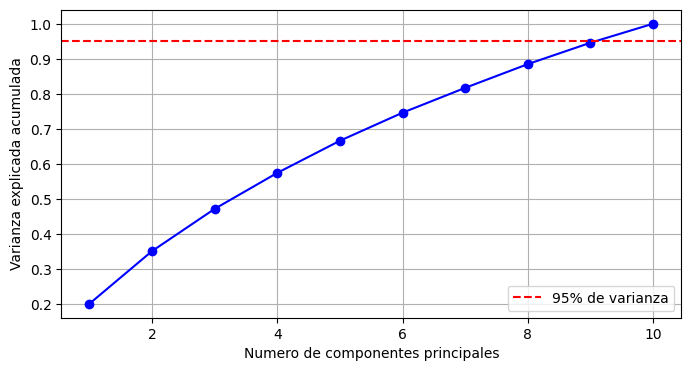

 1 PCs -> 20.20% de varianza explicada
 2 PCs -> 35.21% de varianza explicada
 3 PCs -> 47.24% de varianza explicada
 4 PCs -> 57.49% de varianza explicada
 5 PCs -> 66.65% de varianza explicada
 6 PCs -> 74.65% de varianza explicada
 7 PCs -> 81.73% de varianza explicada
 8 PCs -> 88.49% de varianza explicada
 9 PCs -> 94.58% de varianza explicada
10 PCs -> 100.00% de varianza explicada


In [35]:
# Escalamos: fit SOLO con train (si no, fuga de datos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_set[features])
X_test_scaled = scaler.transform(test_set[features])

# PCA sin argumentos para ver la varianza explicada de cada componente
pca_full = PCA()
pca_full.fit(X_train_scaled)

varianza_acumulada = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, "bo-")
plt.axhline(y=0.95, color="r", linestyle="--", label="95% de varianza")
plt.xlabel("Numero de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.legend()
plt.grid()
plt.show()

for i, v in enumerate(varianza_acumulada, start=1):
    print(f"{i:2d} PCs -> {v*100:.2f}% de varianza explicada")

In [36]:
# Escogemos el numero de componentes en funcion de la varianza explicada: nos quedamos con el 95%
pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Componentes elegidas para el 95% de varianza: {pca.n_components_} (de {len(features)} features)")
print("X_train_pca:", X_train_pca.shape)

Componentes elegidas para el 95% de varianza: 10 (de 10 features)
X_train_pca: (9452, 10)


In [37]:
# Entrenamos el MISMO tipo de modelo ganador, con los mismos hiperparametros optimizados
modelo_pca = grid.best_estimator_.__class__(**grid.best_params_)
modelo_pca.fit(X_train_pca, y_train)

y_pred_pca = modelo_pca.predict(X_test_pca)

print("=== MODELO CON PCA - TEST ===")
print(classification_report(y_test, y_pred_pca))

resultado_pca = recall_score(y_test, y_pred_pca, average="macro")
print("Recall medio con PCA (test)          :", round(resultado_pca, 4))
print("Recall medio con seleccion (test)    :", round(resultado_final, 4))
print("Diferencia (pp):", round((resultado_pca - resultado_final) * 100, 2))

=== MODELO CON PCA - TEST ===
              precision    recall  f1-score   support

           0       0.97      0.79      0.88      2198
           1       0.21      0.72      0.32       166

    accuracy                           0.79      2364
   macro avg       0.59      0.76      0.60      2364
weighted avg       0.92      0.79      0.84      2364

Recall medio con PCA (test)          : 0.7558
Recall medio con seleccion (test)    : 0.7592
Diferencia (pp): -0.34


In [38]:
# Comparamos tambien en validacion cruzada, que es mas fiable que un unico test
cv_pca = np.mean(cross_val_score(modelo_pca, X_train_pca, y_train, cv=5, scoring="balanced_accuracy"))

comparativa_final = pd.DataFrame({
    "enfoque": [f"Seleccion de features ({mejor_lista_nombre}, {len(mejor_lista)} features)",
                f"PCA ({pca.n_components_} componentes, 95% varianza)"],
    "recall_medio_CV": [round(grid.best_score_, 4), round(cv_pca, 4)],
    "recall_medio_TEST": [round(resultado_final, 4), round(resultado_pca, 4)],
})
comparativa_final

,enfoque,recall_medio_CV,recall_medio_TEST
0,"Seleccion de features (visual, 6 features)",0.7670,0.7592
1,"PCA (10 componentes, 95% varianza)",0.7666,0.7558


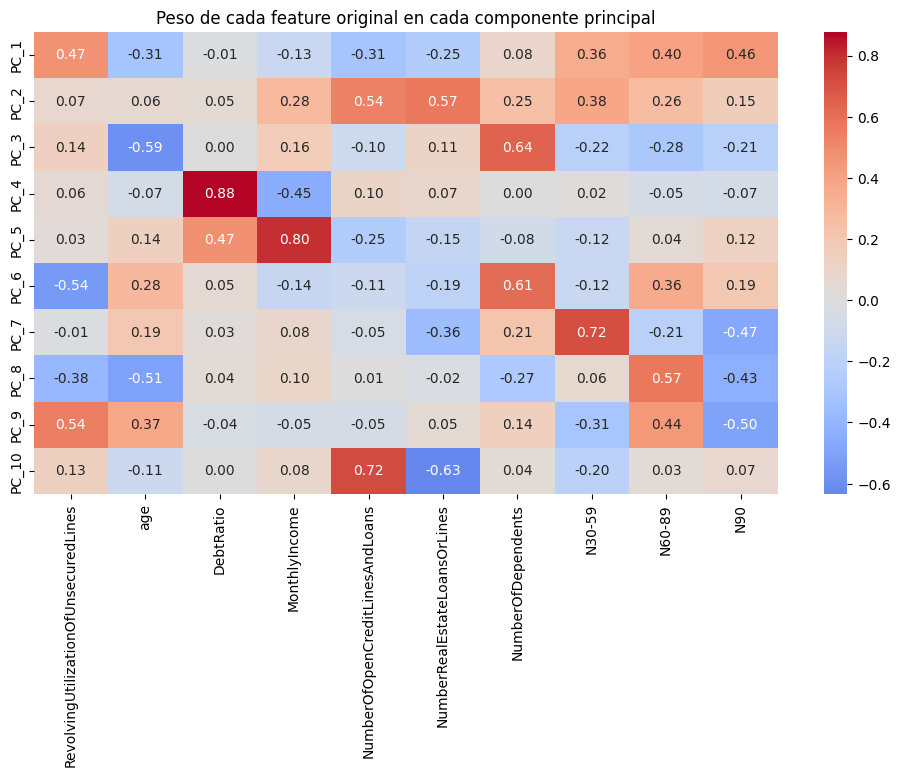

In [39]:
# ¿Que hay dentro de cada componente principal? Asi es como se "explica" una PCA
componentes = pd.DataFrame(pca.components_,
                           columns=features,
                           index=[f"PC_{i+1}" for i in range(pca.n_components_)])

plt.figure(figsize=(12, 6))
sns.heatmap(componentes, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Peso de cada feature original en cada componente principal")
plt.show()

#### Comentario del EXTRA

**Conclusion: la PCA aqui NO merece la pena.** Comparala con la seleccion de features:

| Enfoque | Features que necesita | Recall medio CV | Recall medio TEST |
|---|---|---|---|
| Seleccion de features (visual) | **6** | 0.7670 | **0.7592** |
| PCA (95% de varianza) | **10** (las 10 originales) | 0.7666 | 0.7558 |

* **No mejora el rendimiento**: se queda practicamente igual (0.3 pp por debajo en test). No aporta nada.
* **No comprime NADA**: para llegar al 95% de varianza necesita **las 10 componentes**, es decir, tantas como
  features teniamos. Y tiene todo el sentido: en el heatmap de correlacion vimos que **las features casi no
  estaban correlacionadas entre si**, y la PCA solo puede comprimir cuando hay **redundancia**. Si cada feature
  aporta informacion distinta, no hay nada que condensar. Compara con la practica de PCA de la unidad anterior:
  alli 4096 pixeles (muy redundantes entre si, los pixeles vecinos se parecen) se reducian a 31 componentes.
* **Encima necesita las 10 features originales** para poder calcular las componentes. Con la seleccion nos
  quedamos con 6: en produccion son **4 datos menos que pedir y mantener** por cada cliente. La PCA no nos
  ahorra recoger ni un solo dato.
* **Se carga la explicabilidad**, que en banca es un problema serio (hay que justificar las denegaciones ante
  el regulador). Con la seleccion podemos decir *"denegamos porque el cliente se ha retrasado 2+ veces mas de
  90 dias"*. Con PCA habria que decir *"porque su PC_3 vale -1.7"*, y para traducirlo hay que ir al heatmap de
  componentes y ver que pesa dentro de cada una: farragoso e imposible de defender.

**¿Cuando SI usariamos PCA?** Cuando hay muchisimas features **y muy correlacionadas entre si** (imagenes,
señales, espectros...) y la explicabilidad no es critica. **Aqui, con 10 features poco correlacionadas y con
la obligacion de explicar cada decision, gana la seleccion de features por goleada.**

---

### Conclusion final de la practica

* **Mejor combinacion:** **LightGBM** + la lista **visual/filtrado** (6 features): `N30-59`, `N60-89`, `N90`,
  `RevolvingUtilizationOfUnsecuredLines`, `age`, `NumberOfDependents`.
* **Resultado:** recall medio de **0.767 en CV** y **0.759 en test**. Que ambos numeros se parezcan tanto es
  justo lo que queremos ver: significa que **no hay fuga de datos** y que el modelo generalizara parecido.
* **¿Por que gana la seleccion "visual"?** Es la unica que combina lo mejor de los dos mundos: las **3
  categoricas de retrasos** (que en los graficos separaban clarisimamente) **y** las numericas con mas
  correlacion. Los metodos automaticos tienden a quedarse solo con una parte: `SelectFromModel` y `RFE`
  tiraron `N60-89`, y `SFS` se dejo `age` y `N30-59`. **Moraleja del enunciado ("el conjunto mas sencillo con
  mas potencia"): mirar los datos con ojos de humano sigue ganando a aplicar selectores a ciegas.**
* **Lectura de negocio:** con solo 6 datos del cliente detectamos al **74% de los morosos**. El precio a pagar
  es una precision baja en la clase 1 (0.20): marcamos como sospechosos a muchos que luego pagan bien. Para un
  banco **ese cambio suele compensar** (revisar a mano una solicitud es mucho mas barato que un impago), pero
  es una decision de negocio, no del modelo: moviendo el umbral de probabilidad se puede recalibrar el
  equilibrio entre detectar morosos y molestar a clientes buenos.